In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

/home/deve/myenv/lib/python3.12/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


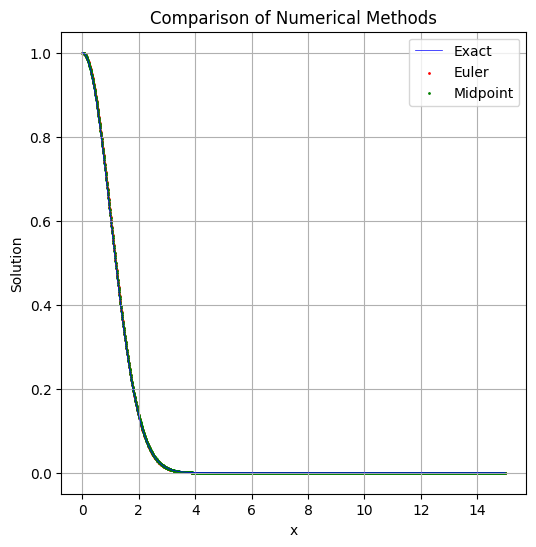

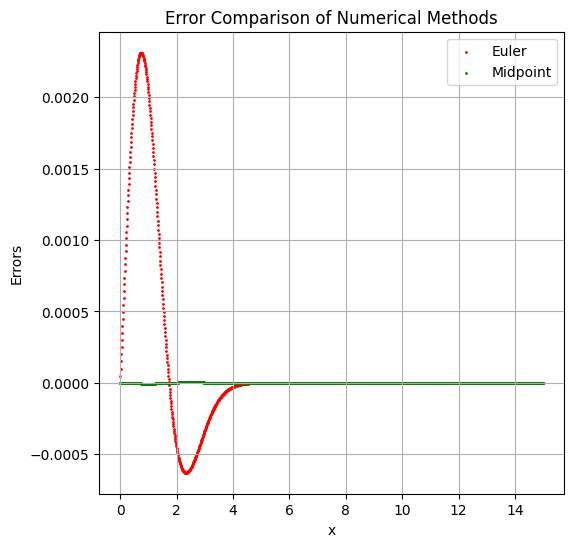

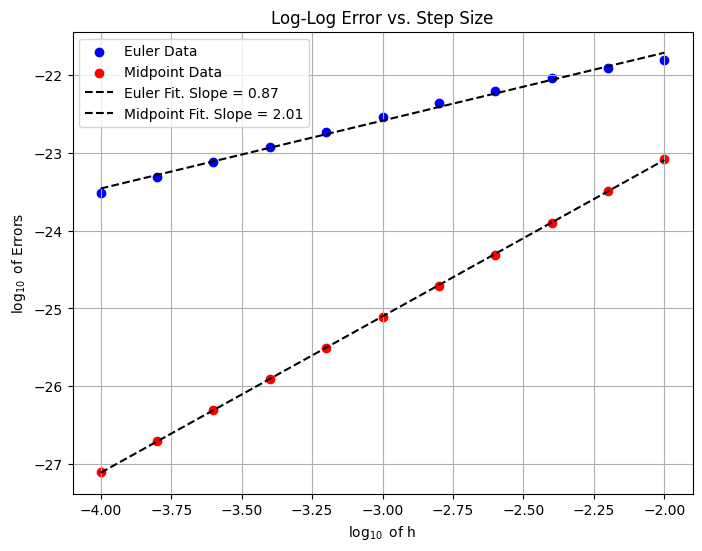

In [3]:
#Q1

#functions
def f(x,t):
    return -1*x*t

def euler(f, x, y, h):
    return y + h * f(x, y)

def midpoint(f, x, y, h):
    k1 = h * f(x, y)
    return y + (h * f(x + h / 2, y + k1 / 2))

def call(method, fn, y_ini, N, xs, h):
    y = y_ini
    ys = np.zeros((N, len(y_ini)))
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = method(fn, x, y, h)
    return ys

h = 1.0e-2
xf = 15

xs = np.arange(x0, xf, h)
N = len(xs) 

y_ini = np.asarray([1.0])  # Initial condition 

# Call the methods
y_euler = call(euler, f, y_ini, N, xs, h)
y_midpoint = call(midpoint, f, y_ini, N, xs, h)

# Generate exact values
y_exact = np.exp(-xs**2 / 2)

plt.figure(figsize=(6, 6))
plt.plot(xs, y_exact, color='blue',label='Exact', linewidth = 0.5)

plt.scatter(xs, y_euler, color='red', s=1, label='Euler')

plt.scatter(xs, y_midpoint, color='green', s=1, label='Midpoint')

plt.xlabel("x")
plt.ylabel("Solution")
plt.legend()
plt.title("Comparison of Numerical Methods")
plt.grid()
plt.show()

# Plotting errors
plt.figure(figsize=(6, 6))
plt.scatter(xs, [y[0] for y in y_euler] - y_exact, color='red', s=1, label='Euler')
plt.scatter(xs, [y[0] for y in y_midpoint] - y_exact, color='green', s=1, label='Midpoint')

plt.xlabel("x")
plt.ylabel("Errors")
plt.legend()
plt.title("Error Comparison of Numerical Methods")
plt.grid()
plt.show()


# Define the range for h
hs = 10.0 ** np.arange(-4.0, -2.0 + 0.2, 0.2)


# Calculate errors at the end
errors_euler = np.zeros(len(hs))
errors_midpoint = np.zeros(len(hs))
for i, h in enumerate(hs):
    xs = np.arange(x0, 10.0 + h, h)  # Generate xs up to 10.0 with step h
    N = len(xs)
    y_exact = np.exp(-xs**2 / 2)
    ys_euler = call(euler, f, y_ini, N, xs, h)
    ys_midpoint = call(midpoint, f, y_ini, N, xs, h)
    errors_euler[i] = abs(ys_euler[-1, 0] - y_exact[-1])
    errors_midpoint[i] = abs(ys_midpoint[-1, 0] - y_exact[-1])

# Error data in log-log format
xd = np.log10(hs)
yd_euler = np.log10(errors_euler)
yd_midpoint = np.log10(errors_midpoint)

# Define the fitting function
def line(x, m, c):
    return x*m + c

# Fit the data
popt_euler, _  = curve_fit(line, xd, yd_euler, p0=[1.0, 1.0])
popt_midpoint, _  = curve_fit(line, xd, yd_midpoint, p0=[1.0, 1.0])

# Generate smooth fit
xfine = np.linspace(xd[0], xd[-1], 1000)
yfine_euler = line(xfine, *popt_euler)
yfine_midpoint = line(xfine, *popt_midpoint)

# Plot the data and the fit
plt.figure(figsize=(8, 6))
plt.scatter(xd, yd_euler, color = "blue", label="Euler Data")
plt.scatter(xd, yd_midpoint, color = "red", label="Midpoint Data")
plt.plot(xfine, yfine_euler, label=f"Euler Fit. Slope = {popt_euler[0]:.2f}", color="k", ls = "--")
plt.plot(xfine, yfine_midpoint, label=f"Midpoint Fit. Slope = {popt_midpoint[0]:.2f}", color="k", ls = "--")
plt.xlabel(r"$\log_{10}$ of h")
plt.ylabel(r"$\log_{10}$ of Errors")
plt.grid()
plt.legend()
plt.title("Log-Log Error vs. Step Size")
plt.show()


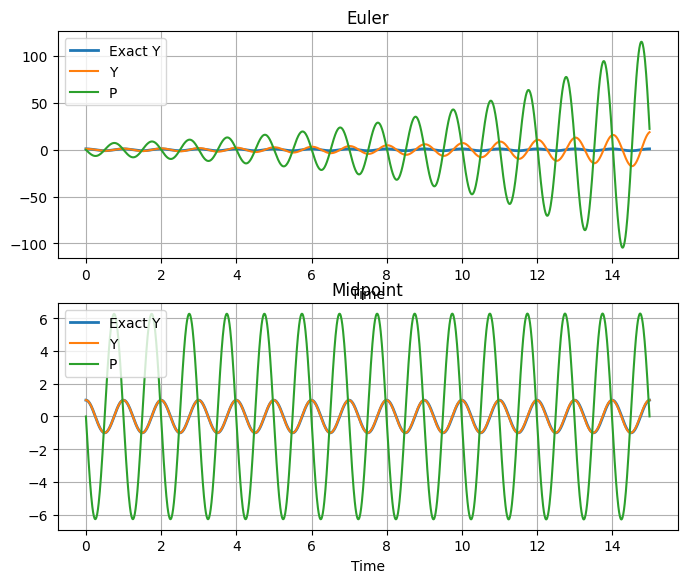

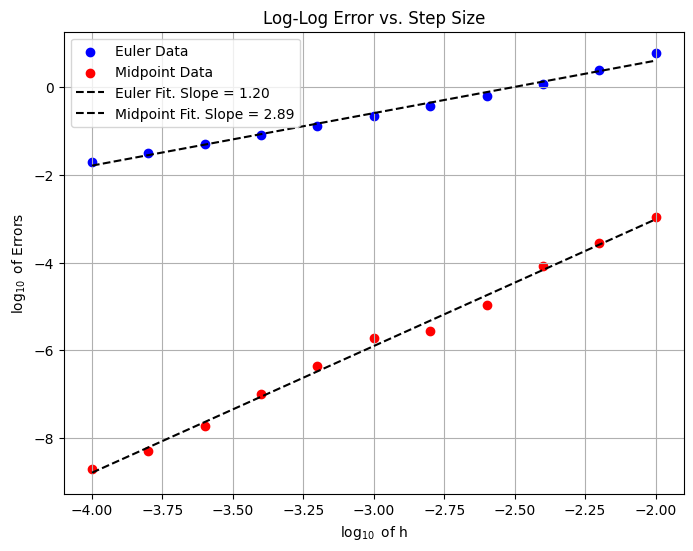

In [5]:
#Q2

#functions
def f(t, y):
    return np.asarray([y[1], -4*(np.pi**2)*y[0]])

def euler(f, x, y, h):
    return y + h * f(x, y)

def midpoint(f, x, y, h):
    k1 = h * f(x, y)
    return y + (h * f(x + h / 2, y + k1 / 2))

def call(method, fn, y_ini, N, xs, h):
    y = y_ini
    ys = np.zeros((N, len(y_ini)))
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = method(fn, x, y, h)
    return ys

h = 1.0e-2
x0 = 0.0
xf = 15

xs = np.arange(x0, xf, h)
N = len(xs)

y_ini = np.asarray([1.0, 0.0])  # Initial condition 

# Call the methods
y_euler = call(euler, f, y_ini, N, xs, h)
y_midpoint = call(midpoint, f, y_ini, N, xs, h)

# Plot for Euler method
plt.figure(figsize=(8, 10))
y_exact = np.cos(2*np.pi*xs)
plt.subplot(3, 1, 1)
plt.plot(xs,y_exact, label = "Exact Y", linewidth = 2)
plt.plot(xs, y_euler[:, 0], label="Y")
plt.plot(xs, y_euler[:, 1], label="P")
plt.xlabel("Time")
plt.title("Euler")
plt.legend()
plt.grid()

# Plot for Midpoint method
plt.subplot(3, 1, 2)
plt.plot(xs,y_exact, label = "Exact Y", linewidth = 2)
plt.plot(xs, y_midpoint[:, 0], label="Y")
plt.plot(xs, y_midpoint[:, 1], label="P")
plt.xlabel("Time")
plt.title("Midpoint")
plt.legend()
plt.grid()


# Define the range for h
hs = 10.0 ** np.arange(-4.0, -2.0 + 0.2, 0.2)


# Calculate errors of position
errors_euler = np.zeros(len(hs))
errors_midpoint = np.zeros(len(hs))
for i, h in enumerate(hs):
    xs = np.arange(x0, 10.0 + h, h)  
    N = len(xs)
    y_exact = np.cos(2*np.pi*xs) 
    ys_euler = call(euler, f, y_ini, N, xs, h)
    ys_midpoint = call(midpoint, f, y_ini, N, xs, h)
    errors_euler[i] = abs(ys_euler[-1, 0] - y_exact[-1])
    errors_midpoint[i] = abs(ys_midpoint[-1, 0] - y_exact[-1])

# Error data in log-log format
xd = np.log10(hs)
yd_euler = np.log10(errors_euler)
yd_midpoint = np.log10(errors_midpoint)

# Define the fitting function
def line(x, m, c):
    return x*m + c

# Fit the data
popt_euler, _  = curve_fit(line, xd, yd_euler, p0=[1.0, 1.0])
popt_midpoint, _  = curve_fit(line, xd, yd_midpoint, p0=[1.0, 1.0])

# Generate smooth fit
xfine = np.linspace(xd[0], xd[-1], 1000)
yfine_euler = line(xfine, *popt_euler)
yfine_midpoint = line(xfine, *popt_midpoint)

# Plot the data and the fit
plt.figure(figsize=(8, 6))
plt.scatter(xd, yd_euler, color = "blue", label="Euler Data")
plt.scatter(xd, yd_midpoint, color = "red", label="Midpoint Data")
plt.plot(xfine, yfine_euler, label=f"Euler Fit. Slope = {popt_euler[0]:.2f}", color="k", ls = "--")
plt.plot(xfine, yfine_midpoint, label=f"Midpoint Fit. Slope = {popt_midpoint[0]:.2f}", color="k", ls = "--")
plt.xlabel(r"$\log_{10}$ of h")
plt.ylabel(r"$\log_{10}$ of Errors")
plt.grid()
plt.legend()
plt.title("Log-Log Error vs. Step Size")
plt.show()